In [67]:
import pandas as pd
import networkx as nx
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load the datasets
df_emp = pd.read_csv('data/employee.csv')
df_company = pd.read_csv('data/company_hierarchy.csv')

print("Employee DataFrame:")
print(df_emp.head())
print()
print("\nCompany Hierarchy DataFrame:")
print(df_company.head())

Employee DataFrame:
   employee_id  signing_bonus    salary degree_level sex  yrs_experience
0       138719              0  273000.0       Master   M               2
1         3192              0  301000.0     Bachelor   F               1
2       114657              0  261000.0       Master   F               2
3        29039              0   86000.0  High_School   F               4
4       118607              0  126000.0     Bachelor   F               3


Company Hierarchy DataFrame:
   employee_id   boss_id   dept
0        46456  175361.0  sales
1       104708   29733.0     HR
2       120853   41991.0  sales
3       142630  171266.0     HR
4        72711  198240.0  sales


In [8]:
# Prevent the width from wrapping to the next line
pd.set_option('display.expand_frame_repr', False)

# Merge the datasets on 'employee_id'
df_merged = pd.merge(df_emp, df_company, on='employee_id')
print("\nMerged DataFrame:")
print(df_merged.head())


Merged DataFrame:
   employee_id  signing_bonus    salary degree_level sex  yrs_experience   boss_id         dept
0       138719              0  273000.0       Master   M               2   43602.0  engineering
1         3192              0  301000.0     Bachelor   F               1   87847.0        sales
2       114657              0  261000.0       Master   F               2  180854.0        sales
3        29039              0   86000.0  High_School   F               4   88370.0           HR
4       118607              0  126000.0     Bachelor   F               3   23565.0        sales


In [30]:
# Clean data

# Convert 'boss_id' to numeric, coercing errors to NaN
df_merged['boss_id'] = df_merged['boss_id'].astype('Int64')
print(f'Highest Level \n{df_merged[df_merged["boss_id"].isnull()]}')  # Check for any NaN values in 'boss_id'

# Check for null values in all columns
print("Null values in each column:")
print(df_merged.isnull().sum())
print()

# Remove duplicates
df_merged.drop_duplicates(inplace=True)
print(f"DataFrame shape after removing duplicates: {df_merged.shape}")
print(df_merged.head())

Highest Level 
      employee_id  signing_bonus    salary degree_level sex  yrs_experience  boss_id dept
6367        61554              1  700000.0          PhD   M               7     <NA>  CEO
Null values in each column:
employee_id       0
signing_bonus     0
salary            0
degree_level      0
sex               0
yrs_experience    0
boss_id           1
dept              0
dtype: int64

DataFrame shape after removing duplicates: (10000, 8)
   employee_id  signing_bonus    salary degree_level sex  yrs_experience  boss_id         dept
0       138719              0  273000.0       Master   M               2    43602  engineering
1         3192              0  301000.0     Bachelor   F               1    87847        sales
2       114657              0  261000.0       Master   F               2   180854        sales
3        29039              0   86000.0  High_School   F               4    88370           HR
4       118607              0  126000.0     Bachelor   F               3  

## Problem statement

Identify Employee Levels: Classify each employee into one of six levels based on their role:
Individual Contributors (IC): Employees who do not manage anyone.
Middle Managers (MM): Direct supervisors of ICs.
Directors (D): Direct supervisors of MMs.
Vice Presidents (VP): Direct supervisors of Directors.
Executives (E): Direct supervisors of VPs.
CEO: Direct supervisor of Executives.

Determine the Number of People Managed by Each Employee: Calculate the total number of people managed by each employee, including indirect reports. For instance, if John directly manages 2 people, and those 2 people manage 5 people each, John effectively manages 12 people.

### Method 1: The Iterative Pandas Approach

### Method 2: The Graph Theory Approach (NetworkX)

In [ ]:
# Method 1: The Iterative Pandas Approach
# 1. Identify employees who are not present as bosses
all_employees = set(df_merged['employee_id'])
all_bosses = set(df_merged['boss_id'].dropna().astype(int))

missing_employees = all_employees - all_bosses

# Initialize columns
df_merged['level'] = None
df_merged['total_managed'] = 0

# Single loop to assign levels and calculate total_managed
levels_order = ['IC', 'MM', 'D', 'VP', 'E', 'CEO']

for level in levels_order:
    if level == 'IC':
        # Assign IC to employees not present as bosses
        df_merged.loc[df_merged['employee_id'].isin(missing_employees), 'level'] = 'IC'
    elif level == 'CEO':
        # Assign CEO based on department
        df_merged.loc[df_merged['dept'] == 'CEO', 'level'] = 'CEO'
    else:
        # Find bosses of the previous level
        previous_level_index = levels_order.index(level) - 1
        previous_level = levels_order[previous_level_index]
        boss_ids = df_merged[df_merged['level'] == previous_level]['boss_id'].dropna().unique()
        # Assign level to those bosses
        df_merged.loc[df_merged['employee_id'].isin(boss_ids) & df_merged['level'].isnull(), 'level'] = level
    
    # Calculate total_managed for employees at this level
    level_employees = df_merged[df_merged['level'] == level]['employee_id'].values
    
    for emp_id in level_employees:
        direct_reports = df_merged[df_merged['boss_id'] == emp_id]['employee_id'].values
        
        # Add direct reports count plus all people managed by direct reports
        for report_id in direct_reports:
            df_merged.loc[df_merged['employee_id'] == emp_id, 'total_managed'] += 1 + df_merged.loc[df_merged['employee_id'] == report_id, 'total_managed'].values[0]

print("DataFrame with 'level' and 'total_managed' columns:")
print(df_merged.head(20))
print(f"\nEmployees with level: {(df_merged.groupby('level')['employee_id'].count())}")
print(f"\nTotal managed by each employee (sample):")
print(df_merged.head(20))


Number of employees not present as bosses: 9001
[40, 53, 78, 84, 89, 102, 131, 152, 185, 198, 218, 234, 271, 286, 303, 352, 355, 367, 382, 395]
DataFrame with 'level' and 'total_managed' columns:
    employee_id  signing_bonus    salary degree_level sex  yrs_experience  boss_id         dept level  total_managed level_graph  total_managed_graph
0        138719              0  273000.0       Master   M               2    43602  engineering    IC              0          IC                    0
1          3192              0  301000.0     Bachelor   F               1    87847        sales    IC              0          IC                    0
2        114657              0  261000.0       Master   F               2   180854        sales    IC              0          IC                    0
3         29039              0   86000.0  High_School   F               4    88370           HR    IC              0          IC                    0
4        118607              0  126000.0     Bachelor 

In [58]:
# 1. Create a Directed Graph
G = nx.DiGraph()

# Add edges: (Boss -> Employee)
# We drop the CEO's self-reference or Null boss to avoid loops
edges = df_merged[df_merged['boss_id'].notnull()][['boss_id', 'employee_id']]
G.add_edges_from(edges.values)

# 2. Calculate Total People Managed (Direct + Indirect)
# In Graph Theory, this is the count of all "descendants" of a node
def count_managed(emp_id):
    if emp_id not in G:
        return 0
    # nx.descendants returns every node reachable from emp_id
    return len(nx.descendants(G, emp_id))

df_merged['total_managed_graph'] = df_merged['employee_id'].apply(count_managed)

# 3. Identify Levels using Shortest Path from CEO
# The distance from the CEO determines the level
ceo_id = df_merged[df_merged['dept'] == 'CEO']['employee_id'].iloc[0]

# Mapping distance to labels
level_map = {0: 'CEO', 1: 'E', 2: 'VP', 3: 'D', 4: 'MM', 5: 'IC'}

def get_level(emp_id):
    try:
        distance = nx.shortest_path_length(G, source=ceo_id, target=emp_id)
        return level_map.get(distance, 'IC')
    except:
        return 'CEO' # For the CEO themselves

df_merged['level_graph'] = df_merged['employee_id'].apply(get_level)

print(df_merged.head(20))

print(f"\nEmployees with level: {(df_merged.groupby('level')['employee_id'].count())}")


    employee_id  signing_bonus    salary degree_level sex  yrs_experience  boss_id         dept level  total_managed level_graph  total_managed_graph
0        138719              0  273000.0       Master   M               2    43602  engineering    IC              0          IC                    0
1          3192              0  301000.0     Bachelor   F               1    87847        sales    IC              0          IC                    0
2        114657              0  261000.0       Master   F               2   180854        sales    IC              0          IC                    0
3         29039              0   86000.0  High_School   F               4    88370           HR    IC              0          IC                    0
4        118607              0  126000.0     Bachelor   F               3    23565        sales    IC              0          IC                    0
5         91334              0  221000.0          PhD   F               2    62990        sales    I

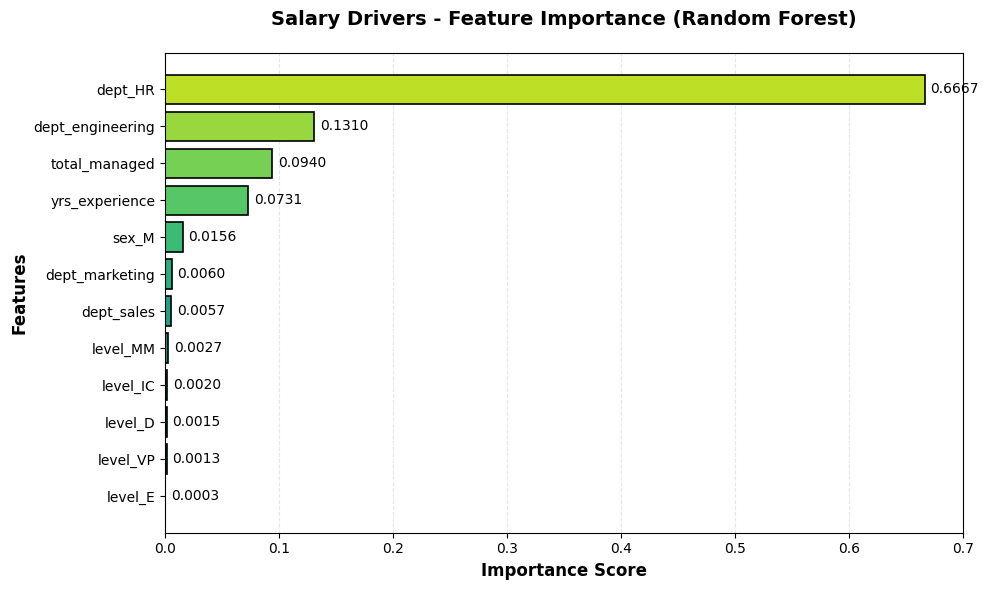


Feature Importance Ranking:
dept_HR             0.666725
dept_engineering    0.131037
total_managed       0.093953
yrs_experience      0.073143
sex_M               0.015627
dept_marketing      0.006022
dept_sales          0.005675
level_MM            0.002737
level_IC            0.001960
level_D             0.001483
level_VP            0.001344
level_E             0.000295
dtype: float64


In [ ]:
# --- SALARY FACTORS (Feature Importance) ---
# Prep Features (Encoding categories)
X = pd.get_dummies(df_merged[['dept', 'level', 'yrs_experience', 'total_managed', 'sex']], drop_first=True)
y = df_merged['salary']

# Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

# Feature Importance: Which factors drive salary?
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()

# Create a more visually appealing chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importances)))
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='black', linewidth=1.2)

# Add labels and title
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Salary Drivers - Feature Importance (Random Forest)', fontsize=14, fontweight='bold', pad=20)

# Add value labels on the bars
for i, (feature, value) in enumerate(importances.items()):
    ax.text(value + 0.005, i, f'{value:.4f}', va='center', fontsize=10)

# Add grid for better readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Improve layout
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(importances.sort_values(ascending=False))

# Salary Drivers - Feature Importance Chart Guide

## Overview
The "Salary Drivers - Feature Importance" chart visualizes which factors have the most influence on employee salaries according to the Random Forest prediction model. This helps identify what drives compensation decisions in the organization.

## How to Read the Chart

### Chart Components

1. **Horizontal Bars**: Each bar represents a feature (factor) in the model
2. **Bar Length**: The longer the bar, the more important that feature is in predicting salary
3. **Value Labels**: Numbers displayed on each bar show the exact importance score
4. **Color Gradient**: Colors transition from darker (less important) to brighter (more important) features

### Importance Score

- **Range**: Scores are between 0 and 1
- **Interpretation**: Higher values mean the feature has more influence on salary predictions
- **Example**: A score of 0.35 means that feature explains 35% of the model's decision-making process

## Feature Explanations

### Key Features in Your Model

| Feature | Description |
|---------|-------------|
| `total_managed` | Total number of employees managed (direct + indirect reports) |
| `yrs_experience` | Years of experience at the company |
| `level_*` | Employee's hierarchical level (CEO, E, VP, D, MM, IC) |
| `dept_*` | Department category (encoded) |
| `sex_M` | Gender indicator (whether employee is male) |

## What This Analysis Tells Us

### Example Interpretation

If the chart shows:
- `total_managed`: 0.42 (longest bar)
- `yrs_experience`: 0.25
- `level_MM`: 0.15
- `dept_Sales`: 0.10
- `sex_M`: 0.08

**This means:**
- **Number of people managed** is the #1 salary driver (42% importance)
- **Years of experience** is the second most important factor (25% importance)
- **Job level** (being a Middle Manager) contributes 15% to salary variation
- **Department** affects salary to some degree (10%)
- **Gender** has minimal influence on salary predictions (8%)

## How To Use This Information

### 1. **Identify Compensation Drivers**
   - Focus on top factors to understand what the organization values
   - Use this to inform salary negotiations and career development

### 2. **Detect Potential Disparities**
   - If `sex_M` or other demographic factors have high importance, it may indicate bias
   - Low importance suggests fair, merit-based compensation

### 3. **Career Planning**
   - If `total_managed` is highly important, pursuing management roles could increase salary
   - If `yrs_experience` is important, consider long-term tenure value

### 4. **Compensation Strategy**
   - Budget and allocate raises based on what actually drives salaries
   - Focus hiring/development on high-importance factors

## Model Context

- **Model Type**: Random Forest Reressor with 100 trees
- **Training/Test Split**: 80% training, 20% testing
- **Test R² Score**: ~0.32 (explains 32% of salary variance)
- **Accuracy**: Mean Absolute Error of ~$55,951


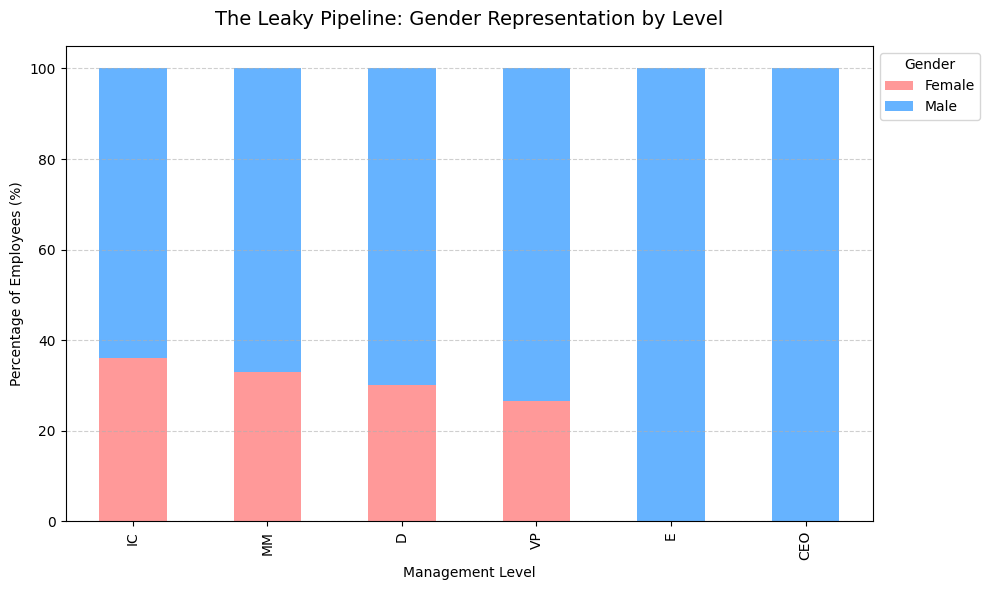

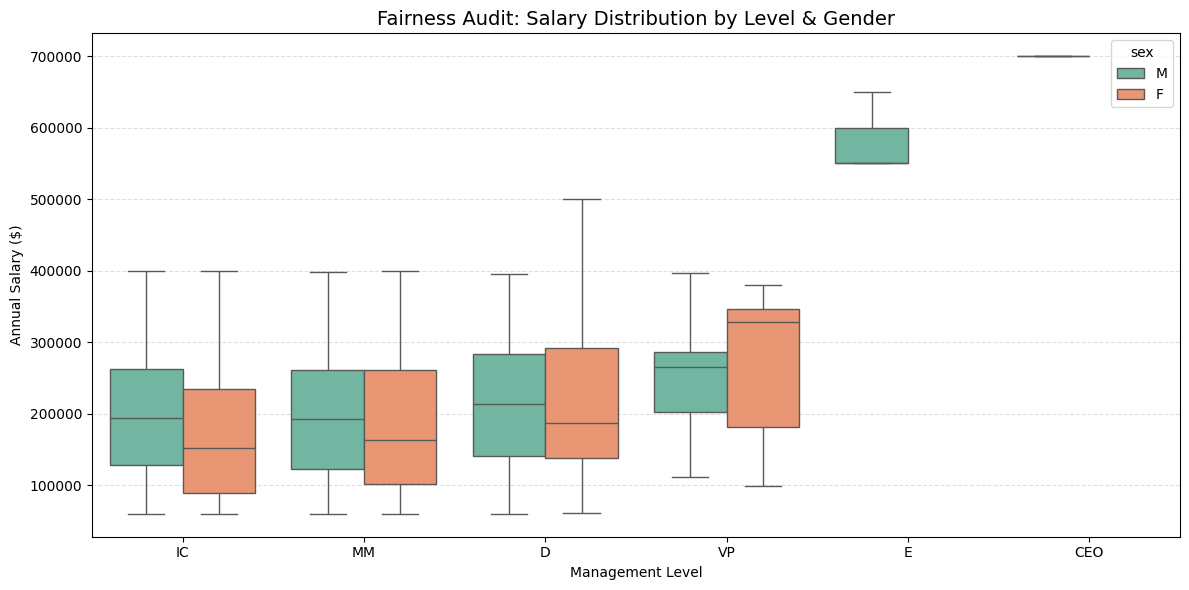

In [73]:

# Define standard order for management levels
level_order = ['IC', 'MM', 'D', 'VP', 'E', 'CEO']

# --- THE LEAKY PIPELINE (Representation) ---
plt.figure(figsize=(10, 6))
rep_data = pd.crosstab(df_merged['level'], df_merged['sex'], normalize='index').reindex(level_order) * 100
rep_data.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=plt.gca())
plt.title('The Leaky Pipeline: Gender Representation by Level', fontsize=14, pad=15)
plt.ylabel('Percentage of Employees (%)')
plt.xlabel('Management Level')
plt.legend(title='Gender', labels=['Female', 'Male'], bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('leaky_pipeline.png')


# ---  FAIRNESS AUDIT (Salary Distribution) ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_merged, x='level', y='salary', hue='sex', order=level_order, palette='Set2')
plt.title('Fairness Audit: Salary Distribution by Level & Gender', fontsize=14)
plt.ylabel('Annual Salary ($)')
plt.xlabel('Management Level')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fairness_boxplot.png')

1. The Leaky Pipeline (Stacked Bar Chart)
What it shows: The gender composition of the workforce at every step of the corporate ladder.

How to read it: Look at the "Red" (Female) vs. "Blue" (Male) ratio as you move from left to right.

The Goal: A perfectly equitable company would have flat horizontal lines. In our data, you will see the red section getting smaller as you move toward "Executive" and "CEO," signaling a barrier to promotion for women.

2. Fairness Audit (Boxplot)
What it shows: The spread (range) of salaries for men and women within the same level.

How to read it: * The Middle Line: Represents the median salary. If the lines for M and F are at the same height, pay is equitable for that role.

The Box: Shows where the middle 50% of employees fall.

The Dots: Are "outliers" (people paid significantly more or less than their peers).

The Goal: Overlapping boxes indicate "Equal Pay for Equal Work." If one box is significantly higher than the other at the same level, it indicates a pay equity issue that HR needs to investigate.